<a href="https://colab.research.google.com/github/Vaibhavrsonawane2000/Customer-Churn-analysis/blob/main/Telco_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv("/content/telco_churn.csv")

# Basic info
df.info()
df.head()

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Handle missing values
df = df.dropna()

# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5043 non-null   int64  
 1   customerID        5043 non-null   object 
 2   gender            5043 non-null   object 
 3   SeniorCitizen     5043 non-null   object 
 4   Partner           5043 non-null   object 
 5   Dependents        5043 non-null   object 
 6   tenure            5043 non-null   int64  
 7   PhoneService      5043 non-null   object 
 8   MultipleLines     4774 non-null   object 
 9   InternetService   5043 non-null   object 
 10  OnlineSecurity    4392 non-null   object 
 11  OnlineBackup      4392 non-null   object 
 12  DeviceProtection  4392 non-null   object 
 13  TechSupport       4392 non-null   object 
 14  StreamingTV       4392 non-null   object 
 15  StreamingMovies   4392 non-null   object 
 16  Contract          5043 non-null   object 


**Explorotary Data Analytics(EDA):-**


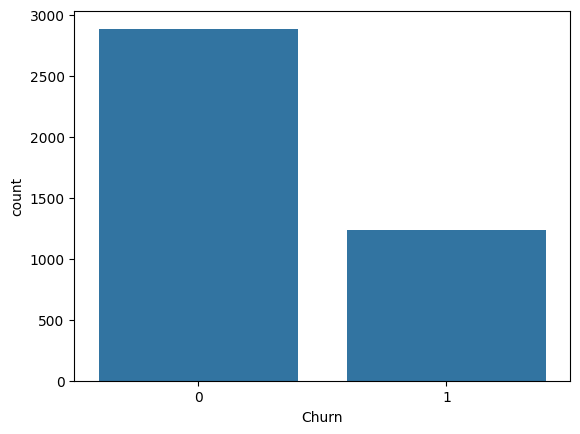

In [ ]:
# Churn distribution
sns.countplot(x='Churn', data=df)
plt.show()

**CHURN INSIGHT:-**

The churn distribution plot shows that the majority of customers in your dataset are 'No Churn', meaning they have not churned. There is a smaller, but significant, proportion of customers who have churned. This indicates an imbalanced dataset, which is common in churn prediction problems.

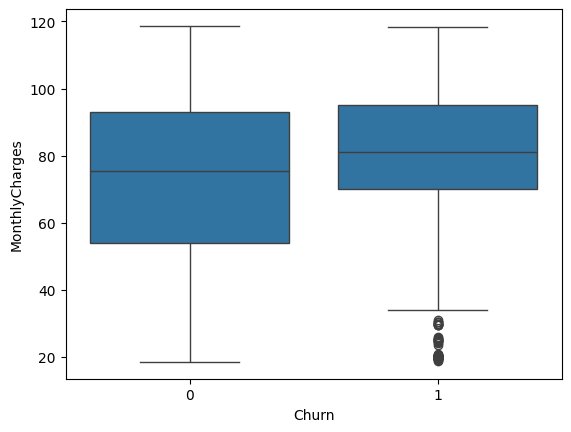

In [ ]:
# Monthly charges vs churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

**MONTHLY CHARGES INSIGHT:-**

Looking at the boxplot for Monthly Charges vs. Churn, it appears that customers who churn tend to have higher monthly charges compared to customers who do not churn. The median monthly charge for churned customers is noticeably higher, and their distribution also skews towards higher values.

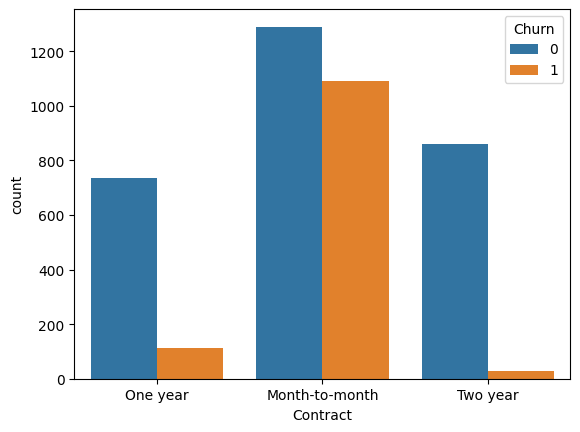

In [ ]:
# Contract vs churn
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

**CONTRACT INSIGHT:-**

Analyzing the 'Contract vs Churn' plot, it appears that customers with a 'Month-to-month' contract have a significantly higher churn rate compared to those with 'One year' or 'Two year' contracts. This suggests that longer-term contracts are associated with lower churn.

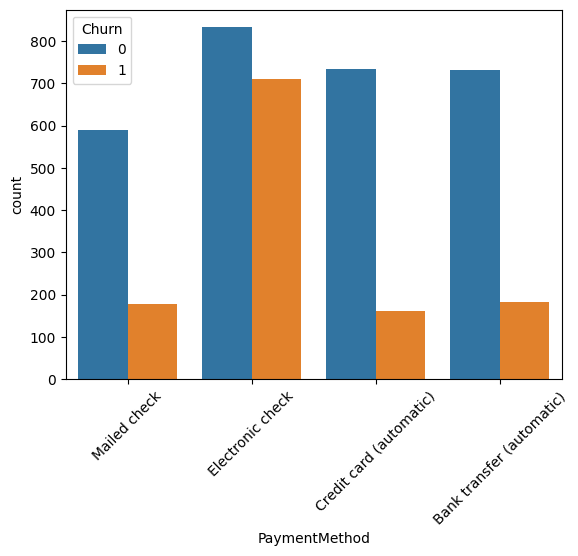

In [ ]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

**PAYMENT METHOD INSIGHT:-**

Analyzing the 'PaymentMethod vs Churn' plot, it appears that customers using 'Electronic check' as their payment method have a significantly higher churn rate compared to other payment methods. 'Bank transfer (automatic)' and 'Credit card (automatic)' show lower churn rates, suggesting that automatic payment methods are associated with higher customer retention.

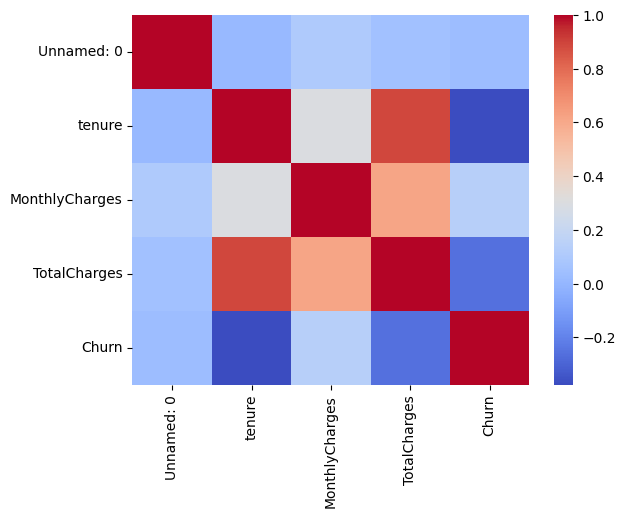

In [ ]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=False, cmap='coolwarm')
plt.show()

In [ ]:
# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

[[491  89]
 [ 97 147]]
Accuracy: 0.7742718446601942


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84       580
           1       0.62      0.60      0.61       244

    accuracy                           0.77       824
   macro avg       0.73      0.72      0.73       824
weighted avg       0.77      0.77      0.77       824

